# Vectorless RAG: Multi-Hop Cross-Reference & Structured Data Retrieval

This notebook demonstrates two advanced use cases where Vectorless RAG outperforms standard chunking-based RAG:

1. **Multi-Hop Cross-Reference Analysis** — fetching discrete variables (dates, limits, conditions) from different parts of a document without introducing noise.
2. **Structured Tables & Rate Charts** — retrieving whole logical nodes that preserve table structure, headers, and footnotes.

Standard Vector RAG often fails here because:
- Chunking shatters tables and cross-references.
- Embedding similarity retrieves irrelevant nearby text.
- Multi-hop reasoning requires fetching multiple distant nodes, which chunking mixes together.

## 1. Prerequisites

This notebook assumes you have:

- A complex, multi-section PDF in a local `data/` folder.
- A PageIndex API key for tree generation.
- A Groq API key for the free LLM endpoint.

The LLM layer uses [Groq](https://groq.com/) via its OpenAI-compatible endpoint. You can choose between `llama-3.3-70b-versatile` (larger) and `llama-3.1-8b-instant` (faster) at runtime.

### API Key Setup

You will need two API keys:

| Key | Where to get it |
|-----|------------------|
| `GROQ_API_KEY` | [https://console.groq.com/keys](https://console.groq.com/keys) |
| `PAGEINDEX_API_KEY` | [https://www.pageindex.ai](https://www.pageindex.ai) |

Set them as environment variables or in a `.env` file in the same directory as this notebook:

```
GROQ_API_KEY=gsk_...
PAGEINDEX_API_KEY=...
```

In [1]:
# --- Package Installation ---
# pageindex: PageIndex SDK for building the document tree (structured hierarchy of sections)
# openai: Async client for Groq's OpenAI-compatible LLM endpoint
# python-dotenv: loads API keys from a .env file into environment variables
# pymupdf (fitz): fallback raw text extraction when PageIndex text is incomplete
# networkx + matplotlib: graph visualization of the retrieval graph (question -> nodes -> cross-refs)
# scipy: required by networkx's Kamada-Kawai layout algorithm for node positioning
%pip install -q --upgrade pageindex openai python-dotenv pymupdf networkx matplotlib scipy 

Note: you may need to restart the kernel to use updated packages.


## 2. Configuration

The notebook reads API keys from a `.env` file or environment variables. If neither is set, you'll be prompted to paste them interactively.

- `GROQ_API_KEY`: Groq API key (from [console.groq.com/keys](https://console.groq.com/keys)).
- `PAGEINDEX_API_KEY`: PageIndex API key.
- `PDF_NAME`: Optional filename in `data/` if you want to pin a specific PDF.

You will be prompted to choose between two Groq models at runtime:
- `llama-3.3-70b-versatile` — larger, more capable.
- `llama-3.1-8b-instant` — faster, lighter.

Groq provides a free OpenAI-compatible endpoint, so no `LLM_BASE_URL` is needed.

In [19]:
# --- Standard library imports ---
from pathlib import Path
import asyncio
import json
import os
import re
import time
from getpass import getpass
from typing import Any

# --- Third-party imports ---
# dotenv: auto-loads API keys from a .env file so you don't paste them every run
# openai: AsyncOpenAI talks to Groq's OpenAI-compatible endpoint; RateLimitError
#         is caught separately for exponential backoff retry
# pageindex: the PageIndex SDK that turns a PDF into a structured section tree
from dotenv import load_dotenv
from openai import AsyncOpenAI, RateLimitError
from pageindex import PageIndexClient
import pageindex.utils as pi_utils

load_dotenv()

# --- Directory and endpoint configuration ---
DATA_DIR = Path("data")
CACHE_DIR = DATA_DIR / "cache"
LLM_BASE_URL = "https://api.groq.com/openai/v1"
PDF_NAME = os.getenv("PDF_NAME")

# --- API key resolution: .env file -> environment variable -> interactive prompt ---
PAGEINDEX_API_KEY = os.getenv("PAGEINDEX_API_KEY", "").strip()
LLM_API_KEY = os.getenv("GROQ_API_KEY", "").strip()

if not PAGEINDEX_API_KEY:
    PAGEINDEX_API_KEY = getpass("Paste your PAGEINDEX_API_KEY (from pageindex.ai): ").strip()
if not LLM_API_KEY:
    LLM_API_KEY = getpass("Paste your GROQ_API_KEY (from console.groq.com/keys): ").strip()

print(f"PAGEINDEX_API_KEY: {'set' if PAGEINDEX_API_KEY else 'NOT SET'}")
print(f"GROQ_API_KEY: {'set' if LLM_API_KEY else 'NOT SET'}")

# --- Model selection ---
# Two Groq-hosted Llama models are available; 70B is more capable for complex
# multi-hop reasoning, 8B is faster for simple lookups.
MODELS = {
    "1": ("llama-3.3-70b-versatile", "Llama 3.3 70B \u2014 larger, more capable"),
    "2": ("llama-3.1-8b-instant", "Llama 3.1 8B \u2014 faster, lighter"),
}

print("Choose an LLM model:")
for key, (name, desc) in MODELS.items():
    print(f"  {key}. {name} \u2014 {desc}")

choice = input("Enter 1 or 2: ").strip()
LLM_MODEL = MODELS.get(choice, MODELS["1"])[0]
print(f"Using model: {LLM_MODEL}")

# --- Client initialization ---
# pi_client: talks to PageIndex API for tree generation/caching
# llm_client: async OpenAI-compatible client pointed at Groq's free endpoint
pi_client = PageIndexClient(api_key=PAGEINDEX_API_KEY) if PAGEINDEX_API_KEY else None
llm_client = AsyncOpenAI(api_key=LLM_API_KEY, base_url=LLM_BASE_URL) if LLM_API_KEY else None


# --- JSON extraction helper ---
# LLMs sometimes wrap JSON in markdown fences or add explanatory text.
# This regex extracts the first {...} block from the response, robust
# against leading/trailing prose.
def extract_json(text: str) -> dict[str, Any]:
    match = re.search(r"\{.*\}", text, re.S)
    if not match:
        raise ValueError(f"Expected JSON output, got: {text[:500]}")
    return json.loads(match.group(0))


# --- Core LLM call with retry ---
# Groq's free tier has aggressive rate limits, so we use exponential
# backoff (1s, 2s, 4s) across up to 4 attempts before giving up.
async def call_llm(system_prompt: str, user_prompt: str, model: str = LLM_MODEL, temperature: float = 0.0) -> str:
    if llm_client is None:
        raise RuntimeError("GROQ_API_KEY is not configured.")
    max_attempts = 4
    for attempt in range(1, max_attempts + 1):
        try:
            response = await llm_client.chat.completions.create(
                model=model,
                temperature=temperature,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt},
                ],
            )
            return response.choices[0].message.content.strip()
        except RateLimitError:
            if attempt == max_attempts:
                raise RuntimeError("Groq service is busy, please try again shortly.") from None
            wait = 2 ** (attempt - 1)
            print(f"Rate limited, retrying in {wait}s... (attempt {attempt}/4)")
            await asyncio.sleep(wait)


# --- LLM call + JSON parse with corrective retry ---
# Calls the LLM, then attempts to parse JSON. If the first response is
# malformed, sends the raw reply back with a corrective instruction.
# This two-stage approach handles cases where the model outputs extra text
# around the JSON on the first try but self-corrects when shown its error.
async def call_llm_and_parse(system_prompt: str, user_prompt: str, model: str = LLM_MODEL, temperature: float = 0.0) -> dict[str, Any]:
    reply = await call_llm(system_prompt, user_prompt, model, temperature)
    try:
        return extract_json(reply)
    except ValueError:
        print("Received malformed JSON, sending one corrective retry...")
        corrective_prompt = f"Your previous reply was not valid JSON:\n\n{reply}\n\nReturn ONLY the valid JSON object, with no extra text, no markdown fences, and no explanation."
        reply2 = await call_llm(system_prompt, corrective_prompt, model, temperature)
        try:
            return extract_json(reply2)
        except ValueError:
            raise RuntimeError("The AI model failed to return valid JSON after 2 attempts. Please try rephrasing your question.")


# --- Text preview helper ---
# Truncates long evidence text for display, keeping output readable in the notebook.
def preview_text(text: str, limit: int = 1200) -> str:
    text = text.strip()
    return text if len(text) <= limit else text[:limit].rstrip() + "..."


import fitz  # PyMuPDF


# --- Raw PDF text extraction via PyMuPDF ---
# Used as a fallback when PageIndex's indexed text is incomplete or truncated.
# page_index is 0-based, matching PyMuPDF's convention.
def extract_raw_page_text(pdf_path: Path, page_index: int) -> str:
    """Extract raw text from a single page of the PDF using PyMuPDF,
    independent of PageIndex. page_index is 0-based."""
    try:
        doc = fitz.open(pdf_path)
        if 0 <= page_index < len(doc):
            text = doc[page_index].get_text()
            doc.close()
            return text
        doc.close()
        return ""
    except Exception:
        return ""


# --- Page alignment verification ---
# PageIndex's page_index field may not match PyMuPDF's 0-based numbering
# exactly (off-by-one, offset differences, etc.). Rather than trusting the
# index blindly, this function searches a small window of nearby pages and
# returns the text of whichever page actually contains the node's title.
# This prevents injecting mismatched content from a wrong page.
def find_matching_page_text(pdf_path: Path, node_title: str, approx_page_index: int, search_radius: int = 2) -> str:
    """
    The node's page_index field may not align exactly with PyMuPDF's
    0-based page numbering (off-by-one or other offset is possible).
    Instead of trusting approx_page_index blindly, search a small window
    of nearby pages and return the text of whichever page actually
    contains the node's own title — this verifies alignment before using
    any extracted text, so a wrong offset can never inject mismatched
    content.
    Returns "" if no nearby page contains the title (safe no-op).
    """
    if not node_title or not node_title.strip():
        return ""
    title_snippet = node_title.strip()[:40].lower()
    candidates = []
    for offset in range(-search_radius, search_radius + 1):
        candidate_page = approx_page_index + offset
        text = extract_raw_page_text(pdf_path, candidate_page)
        if text and title_snippet in text.lower():
            candidates.append((abs(offset), text))
    if not candidates:
        return ""
    # Return the page closest to the approximated index to minimize drift
    candidates.sort(key=lambda pair: pair[0])
    return candidates[0][1]


# --- Continuation page detection ---
# Some sections span multiple pages. This checks whether the next page
# starts with the same section title (or a '(continued)' marker), indicating
# it belongs to the same logical node. The check is done by normalizing both
# the title and the first 300 chars of the next page (lowercasing, removing
# punctuation) so minor formatting differences don't prevent a match.
def find_continuation_page_text(pdf_path: Path, node_title: str, page_idx: int) -> str:
    """
    Check whether the page immediately following this node's page continues
    the same section (e.g. the same title repeated, optionally followed by
    '(continued)' or similar). This is independent of how much text the
    node already has — a node can be long enough to look complete and still
    be missing a continuation on the next page. Returns the next page's raw
    text if it appears to continue this node's section, otherwise "".
    """
    if not node_title or not node_title.strip():
        return ""
    next_page_text = extract_raw_page_text(pdf_path, page_idx + 1)
    if not next_page_text:
        return ""
    import re as _re
    def _normalize(s: str) -> str:
        s = _re.sub(r"[^a-z0-9 ]", " ", s.lower())
        return _re.sub(r"\s+", " ", s).strip()
    title_normalized = _normalize(node_title.strip()[:40])
    next_page_normalized = _normalize(next_page_text[:300])
    if title_normalized and title_normalized in next_page_normalized:
        return next_page_text
    return ""


# --- Tree completeness verification and backfill ---
# Walks every node in the tree and checks whether its text looks truncated
# (fewer chars than min_chars_per_page). If so, it cross-checks against
# a verified PyMuPDF extraction (via find_matching_page_text) and appends
# the raw text as supplemental content. Also detects cross-page continuations
# that PageIndex may have split into a separate node.
# This is a safety net — it catches cases where PageIndex's OCR/summarization
# dropped content, without consuming additional API calls.
def verify_and_backfill_tree(tree: list, pdf_path: Path, min_chars_per_page: int = 400) -> list:
    """
    Walk every node in the tree. If a node's text looks suspiciously
    short relative to what its page likely contains, cross-check against
    a raw PyMuPDF extraction of that page. If the raw extraction is
    meaningfully longer, append the extra raw text to the node so
    nothing is silently missing.
    Returns the tree (modified in place) and prints which nodes, if any,
    were backfilled.
    """
    backfilled_nodes = []

    def walk(nodes):
        for node in nodes:
            node_text = node.get("text", "") or ""
            page_idx = node.get("page_index")
            node_title = node.get("title", "")
            # Check if the node text is suspiciously short for a full page
            if page_idx is not None and len(node_text) < min_chars_per_page:
                raw_text = find_matching_page_text(pdf_path, node_title, page_idx)
                if raw_text and len(raw_text) > len(node_text) * 1.5 and len(raw_text) > min_chars_per_page:
                    node["text"] = (node_text + "\n\n[Supplemental content recovered via verified raw PDF "
                                     "extraction, since the indexed section text appeared incomplete:]\n\n" + raw_text)
                    backfilled_nodes.append(node.get("node_id", node.get("title", "unknown")))
            # Also check for cross-page continuation regardless of text length
            if page_idx is not None:
                continuation_text = find_continuation_page_text(pdf_path, node_title, page_idx)
                if continuation_text and continuation_text not in node["text"]:
                    node["text"] = (node["text"] + "\n\n[Additional continuation content recovered "
                                     "via verified raw PDF extraction from the following page:]\n\n" + continuation_text)
                    backfilled_nodes.append(node.get("node_id", node.get("title", "unknown")) + " (continuation)")

            children = node.get("nodes") or node.get("children") or []
            if children:
                walk(children)

    walk(tree)

    if backfilled_nodes:
        print(f"\u26a0\ufe0f  Backfilled {len(backfilled_nodes)} node(s) that looked incomplete: {backfilled_nodes}")
        print("   (Supplemented using local PyMuPDF extraction \u2014 no additional PageIndex calls were made.)")
    else:
        print("\u2705 Tree completeness check passed \u2014 no nodes appeared truncated.")

    return tree

PAGEINDEX_API_KEY: set
GROQ_API_KEY: set
Choose an LLM model:
  1. llama-3.3-70b-versatile — Llama 3.3 70B — larger, more capable
  2. llama-3.1-8b-instant — Llama 3.1 8B — faster, lighter


Enter 1 or 2:  1


Using model: llama-3.3-70b-versatile


## 3. Load a PDF from `data/`

This notebook works with one user-provided PDF at a time. If `PDF_NAME` is set, the notebook uses that file from `data/`; otherwise it uses the first PDF it finds.

For this lab, use a complex multi-section PDF that contains tables, cross-references, or structured data.

In [20]:
# --- Detect environment: Colab vs local Jupyter ---
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

DATA_DIR.mkdir(exist_ok=True)

if IN_COLAB:
    # --- Colab upload path ---
    from google.colab import files as colab_files
    print("Upload a PDF file (Colab mode):")
    uploaded = colab_files.upload()
    for fname, data in uploaded.items():
        save_path = DATA_DIR / fname
        save_path.write_bytes(data)
        print(f"Saved: {save_path}")
else:
    # --- Local Jupyter upload path (ipywidgets) ---
    import ipywidgets as widgets
    from IPython.display import display

    upload_output = widgets.Output()
    upload_button = widgets.FileUpload(
        description='Upload PDF',
        accept='.pdf',
        multiple=False,
        style={'description_width': 'initial'},
    )
    display(upload_button)

    _saved_files = set()

    def on_upload_change(change):
        with upload_output:
            upload_output.clear_output()
            if change['new']:
                for entry in change['new']:
                    if entry.name in _saved_files:
                        continue
                    if not entry.content:
                        continue
                    save_path = DATA_DIR / entry.name
                    save_path.write_bytes(entry.content)
                    _saved_files.add(entry.name)
                    print(f"Saved: {save_path}")

    upload_button.observe(on_upload_change, names='value')
    display(upload_output)

# --- PDF resolution priority: uploaded > PDF_NAME env > first .pdf in data/ ---
_uploaded_pdf = None
if not IN_COLAB:
    # In local mode, check ipywidgets upload
    if upload_button.value:
        for entry in upload_button.value:
            if entry.content:
                _uploaded_pdf = DATA_DIR / entry.name

if _uploaded_pdf and _uploaded_pdf.exists():
    pdf_path = _uploaded_pdf
else:
    pdf_candidates = sorted(DATA_DIR.glob("*.pdf"))
    if not pdf_candidates:
        raise FileNotFoundError(f"No PDF files found in {DATA_DIR.resolve()}. Upload a PDF above, then re-run this cell.")

    if PDF_NAME:
        matching = [path for path in pdf_candidates if path.name == PDF_NAME]
        if not matching:
            available = ", ".join(path.name for path in pdf_candidates)
            raise FileNotFoundError(f"PDF_NAME={PDF_NAME!r} was not found in data/. Available files: {available}")
        pdf_path = matching[0]
    else:
        pdf_path = pdf_candidates[0]

# --- Validate the PDF before proceeding ---
MAX_PDF_SIZE_MB = 20
with open(pdf_path, "rb") as f:
    header = f.read(4)
if header != b"%PDF":
    raise ValueError(f"{pdf_path.name} does not appear to be a valid PDF file (missing %PDF signature).")

size_mb = pdf_path.stat().st_size / (1024 * 1024)
if size_mb > MAX_PDF_SIZE_MB:
    raise ValueError(f"{pdf_path.name} is {size_mb:.1f} MB, which exceeds the {MAX_PDF_SIZE_MB} MB limit.")

print(f"Using PDF: {pdf_path}")

FileUpload(value=(), accept='.pdf', description='Upload PDF')

Output()

Using PDF: data/synthetic_medicare_plus_policy_detailed.pdf


## 4. Build the PageIndex tree

This cell submits the selected PDF to PageIndex and retrieves the generated tree.

The tree is cached locally in `data/cache/` so subsequent runs skip the PageIndex API call for the same document.

If the document is still processing, the notebook polls with a progress bar until the tree is ready.

In [21]:
# --- Build or load the PageIndex tree ---
# PageIndex processes the PDF into a hierarchical tree of sections, each
# with a title, summary, full text, and page reference. Results are cached
# locally so subsequent runs skip the (slow) API processing step.

CACHE_DIR.mkdir(exist_ok=True)
cache_path = CACHE_DIR / f"{pdf_path.stem}_tree.json"

if cache_path.exists():
    print(f"Loading cached tree from {cache_path}")
    tree = json.loads(cache_path.read_text())
else:
    if pi_client is None:
        raise RuntimeError("PAGEINDEX_API_KEY is not configured.")

    # Submit the PDF to PageIndex for processing
    submitted = pi_client.submit_document(str(pdf_path))
    doc_id = submitted.get("doc_id") or submitted.get("result", {}).get("doc_id")
    if not doc_id:
        raise RuntimeError(f"Could not read doc_id from PageIndex response: {submitted}")

    print(f"Submitted document id: {doc_id}")
    print("Waiting for PageIndex to process the document...")

    # Poll with a spinner until processing completes (up to 5 minutes)
    poll_interval = 5
    max_wait = 300
    elapsed = 0
    spinner = ["|", "/", "-", "\\"]
    while elapsed < max_wait:
        if pi_client.is_retrieval_ready(doc_id):
            break
        idx = (elapsed // poll_interval) % len(spinner)
        print(f"\r  {spinner[idx]}  Waiting... {elapsed}s / {max_wait}s", end="", flush=True)
        time.sleep(poll_interval)
        elapsed += poll_interval
    else:
        raise RuntimeError(
            f"PageIndex did not finish within {max_wait}s. Rerun this cell later."
        )
    print(f"\r  Done! Processed in {elapsed}s.{' ' * 20}")

    tree_response = pi_client.get_tree(doc_id, node_summary=True)
    tree = tree_response.get("result", tree_response)

    cache_path.write_text(json.dumps(tree))
    print(f"Tree cached to {cache_path}")

# --- Backfill: verify completeness and supplement incomplete nodes ---
# Even after PageIndex processing, some nodes may have truncated text.
# verify_and_backfill_tree cross-checks against raw PyMuPDF extraction
# and appends any missing content, then saves the enriched tree.
tree = verify_and_backfill_tree(tree, pdf_path)
cache_path.write_text(json.dumps(tree))

print("Tree ready. Top-level preview:")
pi_utils.print_tree(tree[:2] if isinstance(tree, list) else tree)

Loading cached tree from data/cache/synthetic_medicare_plus_policy_detailed_tree.json
✅ Tree completeness check passed — no nodes appeared truncated.
Tree ready. Top-level preview:
[{'title': 'POLICY WORDING, BENEFIT SCHEDULE AND UND...',
  'node_id': '0000',
  'prefix_summary': 'This text outlines the administrative an...',
  'nodes': [{'title': 'SECTION 3 - INSURING AGREEMENTS',
             'node_id': '0001',
             'prefix_summary': "This section outlines the insurer's obli...",
             'nodes': [{'title': '4.1 Sum Insured Bands',
                        'node_id': '0002',
                        'summary': '### 4.1 Sum Insured Bands\n\n|  Band | Sum...'},
                       {'title': '4.2 Inpatient Hospitalization Benefit',
                        'node_id': '0003',
                        'summary': 'This section outlines the Inpatient Hosp...'},
                       {'title': '4.3 Critical Illness Benefit Table (Ride...',
                        'node_id': '0004

## 5. Prepare retrieval helpers

The next cells use the tree structure for two passes:

1. Tree search: the LLM selects the node IDs most likely to contain the answer.
2. Evidence extraction: the notebook pulls the full text for those nodes and passes it into the final answer prompt.

This keeps the workflow vectorless while still giving you transparent, inspectable retrieval decisions.

In [22]:
# --- Retrieval helpers: bridge between tree structure and LLM prompts ---

# node_map: flat dict keyed by node_id, enabling O(1) lookup of any node
# in the tree. Created by the PageIndex utility from the nested tree list.
node_map = pi_utils.create_node_mapping(tree)

# tree_as_prompt_text: serializes the tree to JSON for LLM prompts, but
# strips the "text" field from every node. This keeps the prompt compact
# (only titles + summaries) so the LLM can reason over structure without
# being overwhelmed by full content. Full text is fetched later for selected nodes.
def tree_as_prompt_text(document_tree: object) -> str:
    tree_copy = document_tree.copy() if isinstance(document_tree, dict) else document_tree
    tree_without_text = pi_utils.remove_fields(tree_copy, fields=["text"])
    return json.dumps(tree_without_text, indent=2)


# collect_node_text: given a list of node IDs, pulls the full text from
# node_map and formats each with metadata headers (node_id, page, title).
# This annotated format lets the LLM trace evidence back to specific
# document locations for explainability.
def collect_node_text(node_ids: list[str]) -> str:
    parts: list[str] = []
    for node_id in node_ids:
        node = node_map.get(node_id)
        if not node:
            continue
        text = node.get("text", "")
        title = node.get("title", node_id)
        page_index = node.get("page_index", "?")
        parts.append(f"[node={node_id} page={page_index} title={title}]\n{text}")
    return "\n\n".join(parts)


print(f"Indexed nodes: {len(node_map)}")

Indexed nodes: 24


In [23]:
# --- Sanity check: confirm the flat node map is populated ---
print(f"Total nodes in node_map: {len(node_map)}")

Total nodes in node_map: 24


In [24]:
# --- Core adjudication pipeline: multi-hop retrieval + LLM-based decision ---
# This is the main entry point for claim adjudication. It orchestrates:
#   1. Decompose the question into discrete facts (identify_required_facts)
#   2. Retrieve evidence for each fact (batched or single-shot)
#   3. Adjudicate using the LLM with endorsement-override and aggregate-limit rules
# The function handles both simple single-fact lookups and complex multi-hop
# questions that require facts from multiple distant document sections.
async def adjudicate_claim(question: str) -> dict[str, Any]:
    # --- Step 1: Decompose the question into independent facts ---
    facts_result = await identify_required_facts(question)
    required_facts = facts_result["required_facts"]

    if not required_facts:
        # --- Single-fact fallback: simple questions don't need decomposition ---
        # If the LLM returned no required facts, treat this as a straightforward
        # single-shot retrieval (same approach as Lab 1).
        retrieval_system_prompt = """
You are a document retrieval assistant for a multi-hop insurance claims adjudication system.

You will receive a user question and a PageIndex tree made of node titles and summaries.
The question may require information from MULTIPLE distant sections of the policy.

Identify ALL node IDs that contain relevant evidence. Common patterns:
- Effective Dates / Policy Period
- Deductible Limits / Waiting Periods
- Coverage Caps / Sublimits
- Exclusions / Conditions
- Definition sections that clarify terms used elsewhere
- Endorsements section — ALWAYS check this section whenever the 
  question involves a deductible, coverage limit, reporting/notice 
  period, or effective date. Endorsements frequently override or 
  amend the base policy text (e.g. a later effective date changing a 
  deductible amount, or a coverage-part-specific notice period 
  overriding a general one). Do not skip this section on the 
  assumption the base policy text is final — always verify whether 
  an endorsement modifies it.

Return valid JSON with this shape:
{
  "thinking": "step-by-step reasoning about which sections are needed and why",
  "node_list": ["node_id_1", "node_id_2", ...],
  "cross_references": [
    {"from": "node_id", "to": "node_id", "reason": "short explanation of how these nodes relate"}
  ]
}

Do not output markdown, prose, or extra keys.
Be thorough — missing a required node means an incomplete adjudication.
""".strip()
        retrieval_user_prompt = f"""
Question:
{question}

PageIndex tree:
{tree_as_prompt_text(tree)}
""".strip()
        retrieval_json = await call_llm_and_parse(retrieval_system_prompt, retrieval_user_prompt)
        selected_node_ids = retrieval_json.get("node_list", [])
        cross_references = retrieval_json.get("cross_references", [])
        evidence_text = collect_node_text(selected_node_ids)
        retrieval_thinking = retrieval_json.get("thinking", "")

        # Broadening retry: if first pass found nothing, re-ask with softer instructions
        if not evidence_text.strip():
            retrieval_user_prompt_broad = f"""
Question:
{question}

PageIndex tree:
{tree_as_prompt_text(tree)}

Note: The initial retrieval returned no evidence. Please be more inclusive and select ANY nodes that could potentially be relevant.
""".strip()
            retrieval_json_broad = await call_llm_and_parse(retrieval_system_prompt, retrieval_user_prompt_broad)
            selected_node_ids_broad = retrieval_json_broad.get("node_list", [])
            cross_references = retrieval_json_broad.get("cross_references", cross_references)
            evidence_text_broad = collect_node_text(selected_node_ids_broad)
            if evidence_text_broad.strip():
                selected_node_ids = selected_node_ids_broad
                evidence_text = evidence_text_broad
                retrieval_thinking = retrieval_json_broad.get("thinking", "")
            else:
                # Even after broadening, nothing found — return a needs_review result
                return {
                    "question": question,
                    "required_facts": [],
                    "fact_results": [],
                    "selected_node_ids": selected_node_ids,
                    "cross_references": cross_references,
                    "evidence_text": "",
                    "decision": "needs_review",
                    "final_answer": "No relevant evidence was found in the document for this question.",
                    "explainability": {},
                    "retrieval_thinking": retrieval_json_broad.get("thinking", ""),
                }
    else:
        # --- Multi-hop path: batched retrieval for all required facts ---
        # Each fact is independently matched to document nodes. The batched
        # approach is more efficient than fetching facts one at a time.
        fact_results = await fetch_all_fact_evidence(required_facts, question)

        # Collect all unique node IDs across all facts
        selected_node_ids = []
        for fr in fact_results:
            for nid in fr["node_ids"]:
                if nid not in selected_node_ids:
                    selected_node_ids.append(nid)
        cross_references = []

        # Format evidence with per-fact labels and FOUND/NOT FOUND status
        # This structured format helps the adjudication LLM distinguish
        # between facts with evidence and those that couldn't be located.
        evidence_parts = []
        for fr in fact_results:
            status = "FOUND" if fr["found"] else "NOT FOUND"
            evidence_parts.append(
                f"[Required fact: {fr['fact']} \u2014 {status}]\n{fr['evidence'] if fr['found'] else '(no evidence located for this fact)'}"
            )
        evidence_text = "\n\n".join(evidence_parts)
        retrieval_thinking = "\n".join(
            f"[{fr['fact']}]: {fr['thinking']}" for fr in fact_results
        )

    # --- Step 3: Adjudication via LLM ---
    # The system prompt encodes two critical insurance adjudication rules:
    #   1. ENDORSEMENT OVERRIDE: endorsements always supersede base policy text.
    #      The answer must cite both the endorsement and the base provision it replaces.
    #   2. AGGREGATE LIMIT ARITHMETIC: when cumulative limits are involved,
    #      the answer must show the math (used + requested vs. limit) not just a conclusion.
    adjudication_system_prompt = """
You are an insurance claims adjudication assistant.

You have been given evidence from multiple sections of an insurance policy, 
labeled by which required fact each piece of evidence answers. Some facts 
may be marked NOT FOUND — treat those as genuinely missing, do not invent 
an answer for them.

CRITICAL RULE ON ENDORSEMENTS: If the evidence contains BOTH a base 
policy provision (e.g. from Section 4 Deductibles, Section 9 Claims 
Conditions) AND an Endorsement (from Section 10) that addresses the 
same topic, the Endorsement controls and overrides the base policy 
text — this is explicitly stated in the base policy itself. You must:
1. Identify whether an endorsement modifies the base provision relevant 
   to this question.
2. If it does, apply the endorsement's terms (not the base policy's) 
   in your final_answer, and check whether the endorsement's effective 
   date applies to the situation described in the question (e.g. an 
   endorsement effective March 1, 2026 only applies to occurrences on 
   or after that date — before that date, the base policy terms apply).
3. Even when the endorsement clearly overrides the base provision (not 
   just in genuinely ambiguous cases), your final_answer is INCOMPLETE and 
   WRONG unless it follows this exact structure: state the endorsement's 
   number, state the endorsement's overriding rule/value, then explicitly 
   say what the base policy's rule/value would have been without the 
   endorsement, using language equivalent to: '[overriding value], per 
   Endorsement No. [X], which supersedes the base policy's [base value] 
   under [base section name].' Do this for any topic — deductibles, notice 
   periods, coverage limits, coinsurance rates, or anything else — not 
   just one specific type of provision. A final_answer that states only 
   the winning number without naming the superseded rule and its source 
   section fails this requirement.
4. If two provisions genuinely conflict with no clear resolution (e.g. 
   two different notice periods both seem to apply and neither is 
   clearly an override of the other), do not silently pick one — set 
   "decision" to "needs_review" and explicitly mention BOTH provisions 
   in final_answer and explainability, noting that they conflict.
Do not default to the first or most prominent evidence you see — 
actively check whether a later-listed endorsement changes the answer 
before finalizing it.

CRITICAL RULE ON AGGREGATE / CUMULATIVE LIMITS: If the evidence 
mentions a cumulative or aggregate limit (a cap that accumulates across 
multiple occurrences or claims within a period) AND an amount already 
paid or used against that limit, you must show the actual arithmetic in 
final_answer — the amount already used, the amount now being requested, 
their sum, the limit, and the remaining headroom (limit minus amount 
already used) — not just state a conclusion like 'limit exceeded' or 
'covered' without the numbers. This applies to any aggregate/cumulative 
limit in the document, not a specific coverage part.

Return valid JSON with this shape:
{
  "decision": "approve" or "deny" or "needs_review",
  "final_answer": "clear, concise answer for the claims adjuster",
  "explainability": {
    "effective_dates": "policy period information found",
    "deductible": "deductible information found",
    "coverage_limits": "coverage cap information found",
    "evidence_used": ["short evidence note 1", "short evidence note 2"]
  }
}

Ground every statement in the provided evidence. Do not invent facts.
""".strip()
    adjudication_user_prompt = f"""
Adjudication question:
{question}

Evidence from policy:
{evidence_text}
""".strip()
    adjudication_json = await call_llm_and_parse(adjudication_system_prompt, adjudication_user_prompt)

    # --- Return a structured result ---
    # Includes: the decision, final answer, explainability breakdown,
    # all selected node IDs, evidence text, and the LLM's retrieval reasoning.
    return {
        "question": question,
        "required_facts": required_facts,
        "fact_results": fact_results if required_facts else [],
        "selected_node_ids": selected_node_ids,
        "cross_references": cross_references,
        "evidence_text": evidence_text,
        "decision": adjudication_json.get("decision", ""),
        "final_answer": adjudication_json.get("final_answer", ""),
        "explainability": adjudication_json.get("explainability", {}),
        "retrieval_thinking": retrieval_thinking,
    }

In [25]:
# --- Table-specific retrieval and answering pipeline ---
# Unlike adjudicate_claim (which decomposes into facts), this function
# is optimized for questions that require reading structured tables,
# rate charts, or schedules. The retrieval prompt specifically instructs
# the LLM to look for tabular nodes and to include continuation nodes
# (tables often split across page breaks in insurance documents).
# The answer prompt requires exact numbers from the table, not approximations.
async def answer_table_question(question: str) -> dict[str, Any]:
    # --- Step 1: Table-aware retrieval ---
    # The system prompt differs from adjudicate_claim: it tells the LLM to
    # prefer ENTIRE table nodes over fragments, and to always check for
    # continuation nodes after page breaks — a common source of missing rows.
    table_retrieval_prompt = """
You are a document retrieval assistant specializing in structured data.

You will receive a user question and a PageIndex tree made of node titles and summaries.
The question likely requires information from a TABLE, CHART, or SCHEDULE in the document.

Look for nodes that contain:
- Rate charts / premium tables
- Benefit schedules / co-pay matrices
- Coverage limit tables
- Any node whose title or summary suggests tabular data

Return valid JSON with this shape:
{
  "thinking": "which table or schedule was identified and why it matches the question",
  "node_list": ["node_id_1", "node_id_2"],
  "cross_references": [
    {"from": "node_id", "to": "node_id", "reason": "short explanation of how these nodes relate"}
  ]
}

Do not output markdown, prose, or extra keys.
Prefer retrieving the ENTIRE table node over partial fragments.
IMPORTANT: Large tables sometimes split across multiple nodes when 
they span a page break in the source document — this is common and you 
must actively check for it every time, not just when it's obvious. 
After selecting a table node, always also inspect the node(s) 
immediately following it in the document (by page order). If that 
following node's title or summary could plausibly relate to the same 
section, table, or schedule — even if you are not fully certain — 
include it in node_list anyway. Err strongly on the side of including 
a possible continuation node rather than omitting one; a missed 
continuation (losing footnotes, additional rows, or a specific 
insured's own rating in a summary line) is a worse outcome than 
retrieving one extra unnecessary node. This applies to any table or 
schedule in any document, not a specific one.
""".strip()
    table_user_prompt = f"""
Question:
{question}

PageIndex tree:
{tree_as_prompt_text(tree)}
""".strip()
    table_json = await call_llm_and_parse(table_retrieval_prompt, table_user_prompt)
    table_node_ids = table_json.get("node_list", [])
    cross_references = table_json.get("cross_references", [])

    # Collect full text for the selected table nodes
    table_evidence = collect_node_text(table_node_ids)

    # Broadening retry if no table evidence was found
    if not table_evidence.strip():
        table_user_prompt_broad = f"""
Question:
{question}

PageIndex tree:
{tree_as_prompt_text(tree)}

Note: The initial retrieval returned no table evidence. Please be more inclusive and select ANY nodes that could potentially contain tabular data.
""".strip()
        table_json_broad = await call_llm_and_parse(table_retrieval_prompt, table_user_prompt_broad)
        table_node_ids_broad = table_json_broad.get("node_list", [])
        cross_references = table_json_broad.get("cross_references", cross_references)
        table_evidence_broad = collect_node_text(table_node_ids_broad)
        if table_evidence_broad.strip():
            table_node_ids = table_node_ids_broad
            table_json = table_json_broad
            table_evidence = table_evidence_broad
        else:
            # No table data found even after broadening
            return {
                "question": question,
                "table_node_ids": table_node_ids,
                "retrieval_thinking": table_json.get("thinking", ""),
                "cross_references": cross_references,
                "table_evidence": "",
                "final_answer": "No relevant table data was found in the document for this question.",
                "table_structure": {},
                "explainability": {},
            }

    # --- Step 2: Answer from the complete table ---
    # The answer prompt requires exact numbers and rates — no approximations.
    # It also asks for the specific row/column that was used, enabling
    # auditability of the table lookup.
    table_answer_prompt = """
You are an insurance benefits assistant answering questions from rate charts and tables.

You have been given complete table data extracted from a policy document.
Answer the user's question by reading the table carefully.

Return valid JSON with this shape:
{
  "final_answer": "specific answer with exact numbers, rates, or limits from the table",
  "table_structure": {
    "table_title": "name or section of the table",
    "relevant_row": "the specific row or cell that answers the question",
    "relevant_column": "the specific column or category"
  },
  "explainability": {
    "evidence_used": ["specific table excerpt that was used"]
  }
}

Always include exact numbers and rates from the table. Do not approximate.
""".strip()
    table_answer_user = f"""
Question:
{question}

Table data:
{table_evidence}
""".strip()
    table_final_json = await call_llm_and_parse(table_answer_prompt, table_answer_user)

    return {
        "question": question,
        "table_node_ids": table_node_ids,
        "retrieval_thinking": table_json.get("thinking", ""),
        "cross_references": cross_references,
        "table_evidence": table_evidence,
        "final_answer": table_final_json.get("final_answer", ""),
        "table_structure": table_final_json.get("table_structure", {}),
        "explainability": table_final_json.get("explainability", {}),
    }

In [26]:
# --- Multi-hop decomposition: break a complex question into discrete lookups ---
# This is the "planning" step — the LLM decides which independent facts need
# to be fetched before an answer can be assembled. For simple single-fact
# questions (e.g. "what is the policy number?"), it returns an empty list,
# signaling that single-shot retrieval is sufficient.
async def identify_required_facts(question: str) -> dict[str, Any]:
    system_prompt = """
You are a claims-adjudication planning assistant.

Given a user's insurance question, identify the discrete, independent
facts that must be looked up in the policy document to answer it fully.
Do NOT attempt to answer the question. Just list what needs to be found.

Examples of discrete facts: "incident date", "policy effective dates",
"applicable coverage part and limits", "deductible amount",
"any endorsement that modifies the deductible or notice period",
"waiting period conditions", "notice/reporting deadline".

If the question is a single, simple, one-fact lookup (e.g. "what is the
policy number?"), return an EMPTY list — do not force decomposition onto
a simple question.

Return valid JSON with this shape:
{
  "required_facts": ["fact 1", "fact 2", ...]
}

Do not output markdown, prose, or extra keys.
""".strip()
    user_prompt = f"Question:\n{question}"
    result = await call_llm_and_parse(system_prompt, user_prompt)
    return {"required_facts": result.get("required_facts", [])}

In [27]:
# --- Single-fact retrieval with broadening retry ---
# Retrieves evidence for ONE specific fact from the document tree.
# The system prompt instructs the LLM to find ONLY nodes relevant to
# this single fact (not other facts), keeping retrieval focused.
# If the first attempt returns no evidence, a broadened retry asks the
# LLM to be more inclusive — this handles edge cases where the initial
# retrieval was too narrow.
async def fetch_fact_evidence(fact: str, question: str) -> dict[str, Any]:
    system_prompt = """
You are a document retrieval assistant for a multi-hop insurance claims 
adjudication system.

You will be given ONE specific fact that needs to be found, plus the 
overall question for context, and a PageIndex tree of node titles and 
summaries. Find ONLY the node(s) relevant to this ONE fact — do not try 
to retrieve evidence for other facts.

If this fact could plausibly be modified or overridden by an endorsement, 
always check the Endorsements section as well as the base policy section.

Return valid JSON with this shape:
{
  "thinking": "short reasoning about which section(s) contain this fact",
  "node_list": ["node_id_1", "node_id_2", ...]
}

Do not output markdown, prose, or extra keys.
""".strip()
    user_prompt = f"""
Required fact to find:
{fact}

Overall question (for context only):
{question}

PageIndex tree:
{tree_as_prompt_text(tree)}
""".strip()
    result = await call_llm_and_parse(system_prompt, user_prompt)
    node_ids = result.get("node_list", [])
    evidence = collect_node_text(node_ids)

    # Broadening retry: if no evidence was found, re-ask with a softer instruction
    if not evidence.strip():
        broadened_prompt = user_prompt + "\n\nNote: The initial attempt found nothing. Be more inclusive."
        result_broad = await call_llm_and_parse(system_prompt, broadened_prompt)
        node_ids_broad = result_broad.get("node_list", [])
        evidence_broad = collect_node_text(node_ids_broad)
        if evidence_broad.strip():
            node_ids = node_ids_broad
            evidence = evidence_broad
            result = result_broad

    return {
        "fact": fact,
        "node_ids": node_ids,
        "thinking": result.get("thinking", ""),
        "evidence": evidence,
        "found": bool(evidence.strip())
    }

In [28]:
# --- Batched multi-fact retrieval with per-fact retry for missing facts ---
# Unlike fetch_fact_evidence (which handles one fact), this sends ALL required
# facts in a single LLM call, asking the model to find nodes for each fact
# independently. This is more efficient but risks the LLM missing some facts.
# To mitigate that, any facts that came back empty after the first pass get
# a targeted broadening retry — only the missing facts are retried, not all.
async def fetch_all_fact_evidence(required_facts: list[str], question: str) -> list[dict[str, Any]]:
    system_prompt = """
You are a document retrieval assistant for a multi-hop insurance claims 
adjudication system.

You will be given a LIST of specific facts that need to be found, plus 
the overall question for context, and a PageIndex tree of node titles 
and summaries. For EACH fact independently, find the node(s) relevant 
to THAT fact only — do not blend evidence across facts.

If a fact could plausibly be modified or overridden by an endorsement, 
always check the Endorsements section as well as the base policy section 
for that fact.

Return valid JSON with this shape, with exactly one entry per required 
fact, in the same order they were given:
{
  "facts": [
    {"fact": "the exact fact text as given", "thinking": "short reasoning", "node_list": ["node_id_1", ...]},
    ...
  ]
}

Do not output markdown, prose, or extra keys.
""".strip()
    facts_list_text = "\n".join(f"- {f}" for f in required_facts)
    user_prompt = f"""
Required facts to find (one entry per fact in your response):
{facts_list_text}

Overall question (for context only):
{question}

PageIndex tree:
{tree_as_prompt_text(tree)}
""".strip()
    result = await call_llm_and_parse(system_prompt, user_prompt)
    entries = result.get("facts", [])

    # Build a lookup from fact text -> LLM response entry, preserving input order
    by_fact = {e.get("fact", ""): e for e in entries}
    fact_results = []
    missing_facts = []
    for fact in required_facts:
        entry = by_fact.get(fact, {})
        node_ids = entry.get("node_list", [])
        evidence = collect_node_text(node_ids)
        if not evidence.strip():
            missing_facts.append(fact)
        fact_results.append({
            "fact": fact,
            "node_ids": node_ids,
            "thinking": entry.get("thinking", ""),
            "evidence": evidence,
            "found": bool(evidence.strip()),
        })

    # Broadening retry: only re-ask for facts that returned no evidence
    if missing_facts:
        broad_facts_list_text = "\n".join(f"- {f}" for f in missing_facts)
        broad_user_prompt = f"""
Required facts to find (one entry per fact in your response):
{broad_facts_list_text}

Overall question (for context only):
{question}

PageIndex tree:
{tree_as_prompt_text(tree)}

Note: The initial attempt found nothing for these facts. Be more inclusive.
""".strip()
        broad_result = await call_llm_and_parse(system_prompt, broad_user_prompt)
        broad_entries = broad_result.get("facts", [])
        broad_by_fact = {e.get("fact", ""): e for e in broad_entries}
        # Update only the missing facts; already-found facts are left untouched
        for fr in fact_results:
            if fr["fact"] in missing_facts:
                entry = broad_by_fact.get(fr["fact"], {})
                node_ids = entry.get("node_list", [])
                evidence = collect_node_text(node_ids)
                if evidence.strip():
                    fr["node_ids"] = node_ids
                    fr["thinking"] = entry.get("thinking", "")
                    fr["evidence"] = evidence
                    fr["found"] = True

    return fact_results

---

## Scenario A: Multi-Hop Cross-Reference Analysis

### The Problem

Many documents require cross-referencing **multiple distant sections** to answer a single question:

- **Dates / Timeframes** (when does something apply?)
- **Limits / Thresholds** (what are the constraints?)
- **Conditions / Requirements** (what rules apply?)

Standard chunking-based RAG retrieves a single chunk. If the relevant facts are in different sections (pages 2 and 15), chunking either misses one or mixes in irrelevant surrounding text.

Vectorless RAG solves this by letting the LLM reason over the **entire tree** and explicitly select multiple node IDs — even if they are far apart in the document.

### Ask a multi-hop cross-reference question

Enter a question that requires fetching facts from multiple sections of the document.
The `adjudicate_claim()` function below runs the full pipeline as **one atomic step**:

1. **Multi-hop tree search** — The LLM receives the entire document tree and explicitly identifies which sections to fetch. Unlike chunking-based RAG, it can select **any combination of nodes** across the entire document, returning structured `thinking` and `node_list` fields.
2. **Evidence extraction** — Each selected node is retrieved in full as a whole logical node. Because Vectorless RAG avoids chunking, there is no noise — just clean, relevant passages from different parts of the document.
3. **Cross-reference answer** — The final LLM call receives all the multi-hop evidence and produces a structured response with a decision, final answer, and explainability breakdown.

Because all three steps run inside a single async function, re-running retrieval for a new question can never silently leave a stale answer from a previous run.

Run the cell below to ask a question, then run the following cells in order to see the full breakdown. If you ask a new question, re-run from this cell down.

In [29]:
# --- Scenario A: ask a multi-hop claims question ---
# Prompts the user for a question that requires facts from multiple sections,
# then runs the full adjudicate_claim pipeline. If you change the question,
# re-run this cell and all cells below it.
ADJUDICATION_QUESTION = input(
    "Enter a multi-hop claims question (e.g., 'Is this claim within the effective dates and below the deductible limit?'): "
).strip()
if not ADJUDICATION_QUESTION:
    raise ValueError("A question is required to continue.")

result_a = await adjudicate_claim(ADJUDICATION_QUESTION)

print("Question:", result_a["question"])

Enter a multi-hop claims question (e.g., 'Is this claim within the effective dates and below the deductible limit?'):  A 55-year-old in Zone A with Band C is hospitalized. The hospital charges    INR 7,000/day for a room. How does the Room Rent Sub-Limit and    Proportionate Deduction apply?


Question: A 55-year-old in Zone A with Band C is hospitalized. The hospital charges    INR 7,000/day for a room. How does the Room Rent Sub-Limit and    Proportionate Deduction apply?


In [30]:
# --- Display: retrieval details for Scenario A ---
# Shows which nodes were selected, the LLM's reasoning for each,
# and any cross-references between nodes.
print(f"Selected {len(result_a['selected_node_ids'])} node(s):", result_a["selected_node_ids"])
print("\nRetrieval reasoning:")
print(result_a["retrieval_thinking"])
if result_a.get("cross_references"):
    print("\nCross-references:")
    for ref in result_a["cross_references"]:
        print(f"  {ref.get('from', '?')} -> {ref.get('to', '?')}: {ref.get('reason', '')}")

Selected 9 node(s): ['0007', '0003', '0008', '0014', '0002', '0009', '0010', '0013', '0022']

Retrieval reasoning:
[Room Rent Sub-Limit amount or percentage]: The Room Rent Sub-Limit is determined based on the policy Band and geographic Zone. For Zone A and Band C, we need to refer to the specific section that outlines room rent and ICU sub-limits.
[applicable coverage part and limits for hospitalization]: The applicable coverage part and limits for hospitalization can be found in the section that outlines the Inpatient Hospitalization Benefit, which details coverage for room, ICU, medical, and surgical expenses.
[Proportionate Deduction clause details]: The Proportionate Deduction clause details can be found in the section that applies to Bands A and B, where the Sub-Limit is breached, and it outlines the formula for calculating the proportionate deduction.
[Zone A and Band C specific policy terms]: The specific policy terms for Zone A and Band C can be found in the sections that outl

In [35]:
# --- Display: evidence preview and adjudication result ---
# Shows the retrieved evidence text (truncated for readability),
# the final decision (approve/deny/needs_review), and the explainability
# breakdown that maps to specific policy sections.
print("\nEvidence preview (multi-hop):\n")
print(preview_text(result_a["evidence_text"], limit=4000) if result_a["evidence_text"] else "(none)")
print("\nDecision:", result_a["decision"])

print("\nExplainability:")
print(json.dumps(result_a["explainability"], indent=2))


Evidence preview (multi-hop):

[Required fact: Room Rent Sub-Limit amount or percentage — FOUND]
[node=0007 page=4 title=4.6 Room Rent & ICU Sub-Limit Table (per day, by Zone and Band)]
### 4.6 Room Rent & ICU Sub-Limit Table (per day, by Zone and Band)

|  Band | Zone A (metro) | Zone B (tier-2) | Zone C (tier-3)  |
| --- | --- | --- | --- |
|  A | 4,000 | 3,200 | 2,500  |
|  B | 6,000 | 4,800 | 3,800  |
|  C | No Sub-Limit (up to Single Private Room, actual category)  |   |   |
|  D | No Sub-Limit (up to Single Private Room, actual category)  |   |   |
|  E | No Sub-Limit (up to Suite category)  |   |   |

ICU Charges: 2x the applicable Room Rent Sub-Limit shown above for Bands A and B; no sub-limit for Bands C, D, and E.

Footnote (4.6-a): Zone is determined per Clause 5.1 by the Insured Person's city of residence at the time of the claim, which may differ from the Zone used to rate the policy at inception if the Insured Person has since relocated - see Clause 7.11 (Change of Zone)

In [34]:
# --- Display: final adjudication answer ---
print("\nFinal answer:")
print(result_a["final_answer"])


Final answer:
The room rent of INR 7,000/day is eligible for reimbursement up to the Single Private Room category, per the Room Rent & ICU Sub-Limit Table (Clause 4.6), which supersedes any potential sub-limit for Bands A and B. The base policy's rule would have been to apply a sub-limit for room rent, but this is overridden by the 'No Sub-Limit' provision for Band C in Zone A.


In [32]:
# --- Groundedness check: verify the answer is supported by evidence ---
# Sends the final answer and evidence text back to the LLM as a fact-checker.
# If the answer references facts not present in the evidence (hallucination),
# a warning is printed. This is a quality gate, not a hard block.
if result_a["evidence_text"].strip():
    groundedness_system_prompt = """
You are a fact-checking assistant. You will be given an answer and the
evidence text it was supposed to be based on. Determine whether the
answer's claims are actually supported by the evidence.

Return valid JSON with this shape:
{
  "grounded": true or false,
  "reason": "one short sentence explaining your judgment"
}

Do not output markdown, prose, or extra keys.
""".strip()

    groundedness_user_prompt = f"""
Answer to check:
{result_a['final_answer']}

Evidence it should be based on:
{result_a['evidence_text']}
""".strip()

    try:
        groundedness_json = await call_llm_and_parse(groundedness_system_prompt, groundedness_user_prompt)
        if groundedness_json.get("grounded") is False:
            print("\n\u26a0\ufe0f  GROUNDEDNESS WARNING: This answer may not be fully supported by the retrieved evidence.")
            print(f"   Reason: {groundedness_json.get('reason', 'No reason given.')}")
        else:
            print("\n\u2705 Groundedness check passed: answer is supported by the retrieved evidence.")
    except Exception:
        print("\n(Groundedness check could not be completed.)")


⚠️  GROUNDEDNESS WARNING: This answer may not be fully supported by the retrieved evidence.
   Reason: The answer mentions a specific room rent of INR 7,000/day, which is not mentioned in the evidence text.


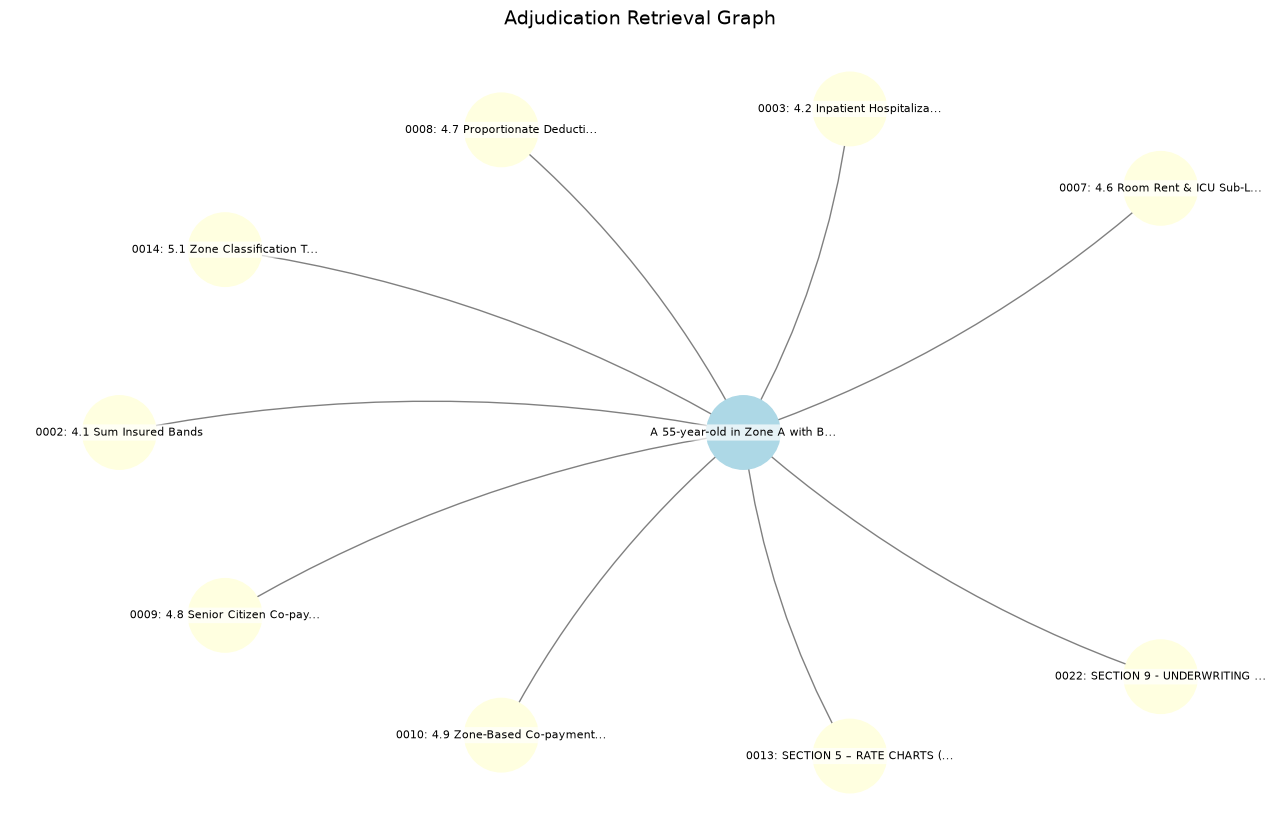

In [33]:
# --- NetworkX visualization: adjudication retrieval graph ---
# Builds a directed graph showing: Question (blue) -> Selected Nodes (yellow)
# with cross-reference edges between nodes. Uses Kamada-Kawai layout
# (requires scipy) for a clean, non-overlapping arrangement.
try:
    import networkx as nx
    import matplotlib.pyplot as plt
    G = nx.DiGraph()
    # Truncate the question label for readability in the graph
    _q_label = result_a['question'][:30] + ('...' if len(result_a['question']) > 30 else '')
    G.add_node(_q_label, color='lightblue')
    # Add each selected node with a truncated title label
    _node_titles = {}
    for nid in result_a['selected_node_ids']:
        _node = node_map.get(nid, {})
        _title = _node.get('title', nid)[:25]
        _full_title = _node.get('title', nid)
        _label = f"{nid}: {_title}" + ('...' if len(_full_title) > 25 else '')
        _node_titles[nid] = _label
        G.add_node(_label, color='lightyellow')
        G.add_edge(_q_label, _label)
    # Add cross-reference edges between selected nodes
    for ref in result_a.get('cross_references', []):
        _src = _node_titles.get(ref.get('from', ''), ref.get('from', ''))
        _tgt = _node_titles.get(ref.get('to', ''), ref.get('to', ''))
        if _src in G.nodes and _tgt in G.nodes:
            G.add_edge(_src, _tgt)
    # Color nodes by their assigned color attribute
    _colors = [G.nodes[n].get('color', 'white') for n in G.nodes]
    fig, ax = plt.subplots(figsize=(14, 9))
    pos = nx.kamada_kawai_layout(G)
    nx.draw_networkx_nodes(G, pos, node_color=_colors, node_size=2800, ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True,
                           arrowstyle='->', arrowsize=15, ax=ax,
                           connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_labels(G, pos, font_size=8, ax=ax,
                            bbox=dict(boxstyle='round,pad=0.2',
                                      facecolor='white', edgecolor='none',
                                      alpha=0.7))
    ax.set_title('Adjudication Retrieval Graph', fontsize=14, pad=12)
    ax.set_axis_off()
    fig.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.05)
    plt.show()
except Exception as e:
    print(f"\n(Visualization unavailable: {type(e).__name__}: {e})")

---

## Scenario B: Structured Tables & Rate Charts

### The Problem

Documents often contain structured tables — comparison charts, schedules, matrices, or rate cards — that are critical for accurate answers.

Standard chunking **shatters** tables:
- A table spanning one page might be split into 3-4 chunks.
- Headers get separated from their rows.
- Footnotes referencing table cells get lost.
- The LLM receives disconnected table fragments with no structural context.

Vectorless RAG retrieves **whole logical nodes**. PageIndex preserves table structure as a single node, so the LLM receives the complete table with headers, data, and footnotes intact.

### Ask a table-related question

Enter a question that requires reading a specific rate chart or data table.
The `answer_table_question()` function below runs the full pipeline as **one atomic step**:

1. **Targeted tree search** — The LLM identifies which node(s) contain the relevant table, reasoning about table headers and row labels in the tree. Because PageIndex preserves table structure, it can pinpoint the right schedule or chart.
2. **Table evidence extraction** — The full table node is retrieved as a whole logical node, preserving the complete structure: headers, rows, data, and footnotes. No chunking splits tables across fragments.
3. **Table-based answer** — The final LLM call reads the complete table and answers the specific rate or benefit question, returning exact numbers and a structured response.

Because all three steps run inside a single async function, re-running retrieval for a new question can never silently leave a stale answer from a previous run.

Run the cell below to ask a question, then run the following cells in order to see the full breakdown. If you ask a new question, re-run from this cell down.

In [36]:
# --- Scenario B: ask a table-related question ---
# Prompts for a question that requires reading rate charts or schedules,
# then runs the full answer_table_question pipeline.
TABLE_QUESTION = input(
    "Enter a table-related question (e.g., 'What is the coinsurance rate for out-of-network providers?'): "
).strip()
if not TABLE_QUESTION:
    raise ValueError("A question is required to continue.")

result_b = await answer_table_question(TABLE_QUESTION)

print("Question:", result_b["question"])

Enter a table-related question (e.g., 'What is the coinsurance rate for out-of-network providers?'):  For a 55-year-old (AG4) in Zone A with Band D and controlled hypertension,    what is the approximate annual premium before GST?


Question: For a 55-year-old (AG4) in Zone A with Band D and controlled hypertension,    what is the approximate annual premium before GST?


In [37]:
# --- Display: table retrieval details for Scenario B ---
# Shows which table nodes were selected, the LLM's reasoning, and cross-references.
print(f"Selected {len(result_b['table_node_ids'])} node(s):", result_b["table_node_ids"])
print("\nRetrieval reasoning:")
print(result_b["retrieval_thinking"])
if result_b.get("cross_references"):
    print("\nCross-references:")
    for ref in result_b["cross_references"]:
        print(f"  {ref.get('from', '?')} -> {ref.get('to', '?')}: {ref.get('reason', '')}")

Selected 5 node(s): ['0015', '0016', '0017', '0019', '0020']

Retrieval reasoning:
The question requires information about the annual premium for a 55-year-old in Zone A with Band D and controlled hypertension. The relevant table is likely to be in the 'RATE CHARTS (UNDERWRITING RATE MANUAL)' section. The '5.2 Base Rate Table' seems to be the most relevant, but it does not directly provide the premium. However, it mentions that rates are 'before Zone Multiplier, Age Loading, or PED Loading', which implies that additional tables or factors are needed to calculate the final premium. The '5.3 Zone Multiplier Table' and '5.9 Pre-Existing Disease (PED) Loading Table' might be necessary to determine the final premium. Since the question asks for an approximate annual premium, we should also consider the '5.12 Long-Term Policy Discount Table' for potential discounts.

Cross-references:
  0015 -> 0016: Zone Multiplier is needed to calculate the final premium
  0015 -> 0017: PED Loading is need

In [39]:
# --- Display: table evidence and structure breakdown ---
# Shows the retrieved table data (truncated), the identified table structure
# (title, relevant row/column), and the explainability breakdown.
print("\nTable evidence preview:\n")
print(preview_text(result_b["table_evidence"], limit=4000) if result_b["table_evidence"] else "(none)")

print("\nTable reference:")
print(json.dumps(result_b["table_structure"], indent=2))
print("\nExplainability:")
print(json.dumps(result_b["explainability"], indent=2))


Table evidence preview:

[node=0015 page=5 title=5.2 Base Rate Table (Rate per Mille of Sum Insured, per Annum, Age Band AG2 [see 5.4], Individual variant, before Zone Multiplier, Age Loading, or PED Loading)]
### 5.2 Base Rate Table (Rate per Mille of Sum Insured, per Annum, Age Band AG2 [see 5.4], Individual variant, before Zone Multiplier, Age Loading, or PED Loading)

|  Plan Variant (1,2) | Column A (Band A) | Column B (Band B) | Column C (Band C) | Column D (Band D) | Column E (Band E)  |
| --- | --- | --- | --- | --- | --- |
|  Individual | 8.20 | 7.65 | 6.90 | 6.10 | 5.40  |
|  Family Floater (2 adults) | 14.50 | 13.60 | 12.30 | 10.90 | 9.70  |
|  Family Floater (2 adults + kids) | 17.80 | 16.70 | 15.10 | 13.40 | 11.90  |

Footnote (5.2-a): Columns correspond exactly to the Sum Insured Bands in Clause 4.1 – do not apply a Column rate to a different Band.

Footnote (5.2-b): Family Floater rates already reflect the shared-pool mechanics of Clause 3.5 and are NOT simply the Indiv

In [40]:
# --- Display: final table answer ---
print("\nFinal answer:")
print(result_b["final_answer"])


Final answer:
13,627.20


In [41]:
# --- Groundedness check for table answer ---
if result_b["table_evidence"].strip():
    groundedness_system_prompt = """
You are a fact-checking assistant. You will be given an answer and the
evidence text it was supposed to be based on. Determine whether the
answer's claims are actually supported by the evidence.

Return valid JSON with this shape:
{
  "grounded": true or false,
  "reason": "one short sentence explaining your judgment"
}

Do not output markdown, prose, or extra keys.
""".strip()

    groundedness_user_prompt = f"""
Answer to check:
{result_b['final_answer']}

Evidence it should be based on:
{result_b['table_evidence']}
""".strip()

    try:
        groundedness_json = await call_llm_and_parse(groundedness_system_prompt, groundedness_user_prompt)
        if groundedness_json.get("grounded") is False:
            print("\n\u26a0\ufe0f  GROUNDEDNESS WARNING: This answer may not be fully supported by the retrieved evidence.")
            print(f"   Reason: {groundedness_json.get('reason', 'No reason given.')}")
        else:
            print("\n\u2705 Groundedness check passed: answer is supported by the retrieved evidence.")
    except Exception:
        print("\n(Groundedness check could not be completed.)")


⚠️  GROUNDEDNESS WARNING: This answer may not be fully supported by the retrieved evidence.
   Reason: The answer is a numerical value without context or explanation.


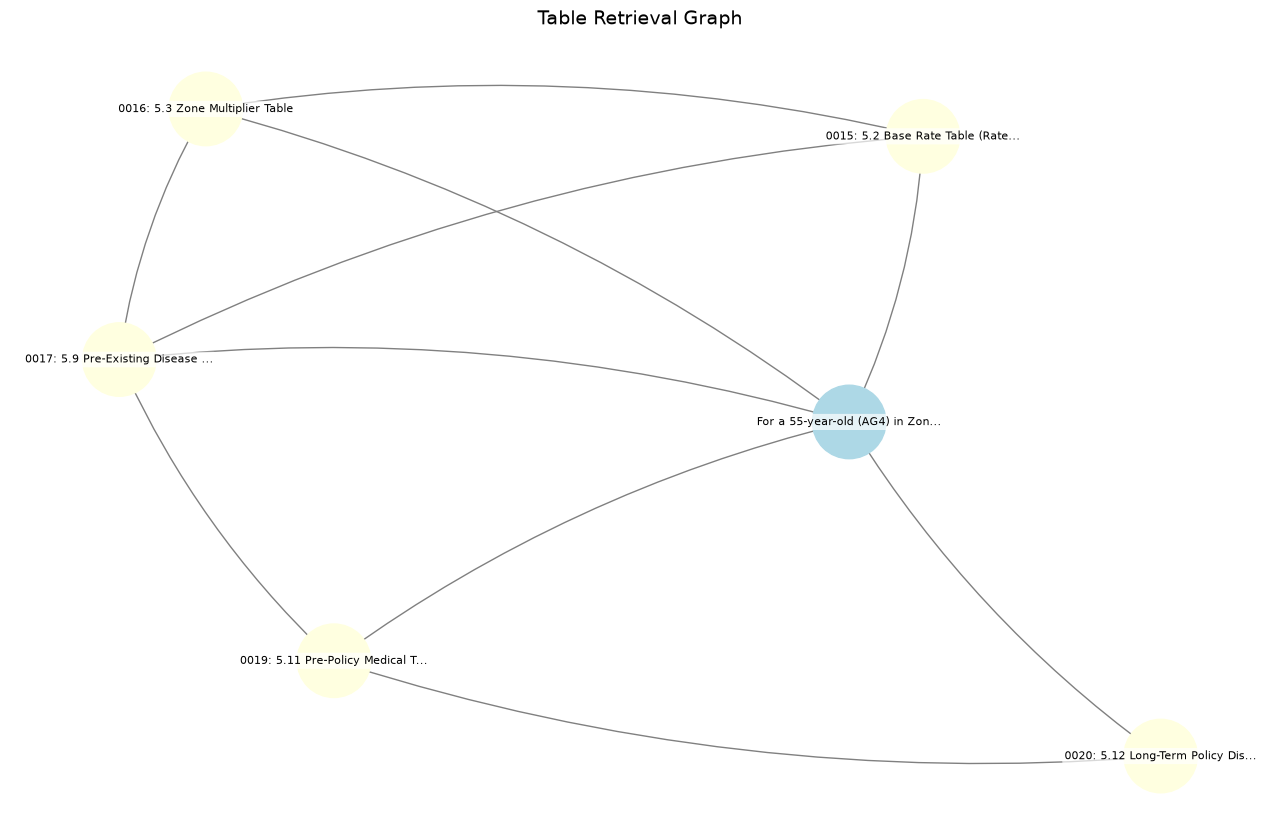

In [42]:
# --- NetworkX visualization: table retrieval graph ---
# Same structure as the adjudication graph but for the table scenario.
# Shows Question (blue) -> Table Nodes (yellow) with cross-reference edges.
try:
    import networkx as nx
    import matplotlib.pyplot as plt
    G = nx.DiGraph()
    _q_label = result_b['question'][:30] + ('...' if len(result_b['question']) > 30 else '')
    G.add_node(_q_label, color='lightblue')
    _node_titles = {}
    for nid in result_b['table_node_ids']:
        _node = node_map.get(nid, {})
        _title = _node.get('title', nid)[:25]
        _full_title = _node.get('title', nid)
        _label = f"{nid}: {_title}" + ('...' if len(_full_title) > 25 else '')
        _node_titles[nid] = _label
        G.add_node(_label, color='lightyellow')
        G.add_edge(_q_label, _label)
    for ref in result_b.get('cross_references', []):
        _src = _node_titles.get(ref.get('from', ''), ref.get('from', ''))
        _tgt = _node_titles.get(ref.get('to', ''), ref.get('to', ''))
        if _src in G.nodes and _tgt in G.nodes:
            G.add_edge(_src, _tgt)
    _colors = [G.nodes[n].get('color', 'white') for n in G.nodes]
    fig, ax = plt.subplots(figsize=(14, 9))
    pos = nx.kamada_kawai_layout(G)
    nx.draw_networkx_nodes(G, pos, node_color=_colors, node_size=2800, ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True,
                           arrowstyle='->', arrowsize=15, ax=ax,
                           connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_labels(G, pos, font_size=8, ax=ax,
                            bbox=dict(boxstyle='round,pad=0.2',
                                      facecolor='white', edgecolor='none',
                                      alpha=0.7))
    ax.set_title('Table Retrieval Graph', fontsize=14, pad=12)
    ax.set_axis_off()
    fig.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.05)
    plt.show()
except Exception as e:
    print(f"\n(Visualization unavailable: {type(e).__name__}: {e})")